# Assignment 1: Student Performance Prediction


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

In [21]:
df = pd.read_csv("student_habits_performance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [23]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [24]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [25]:
numeric_df = df.select_dtypes(include=[np.number])
print("Numeric columns mein missing values:")
print(numeric_df.isnull().sum())

Numeric columns mein missing values:
age                      0
study_hours_per_day      0
social_media_hours       0
netflix_hours            0
attendance_percentage    0
sleep_hours              0
exercise_frequency       0
mental_health_rating     0
exam_score               0
dtype: int64


In [26]:
numeric_df = df.select_dtypes(include=[np.number])

target = "exam_score"

features = [col for col in numeric_df.columns if col != target]

print("Features:", features)
print("Target:", target)

Features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Target: exam_score


In [27]:
X = numeric_df[features]   # Independent variables
y = numeric_df[target]      # Dependent variable 

X.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating
0,23,0.0,1.2,1.1,85.0,8.0,6,8
1,20,6.9,2.8,2.3,97.3,4.6,6,8
2,21,1.4,3.1,1.3,94.8,8.0,1,1
3,23,1.0,3.9,1.0,71.0,9.2,4,1
4,19,5.0,4.4,0.5,90.9,4.9,3,1


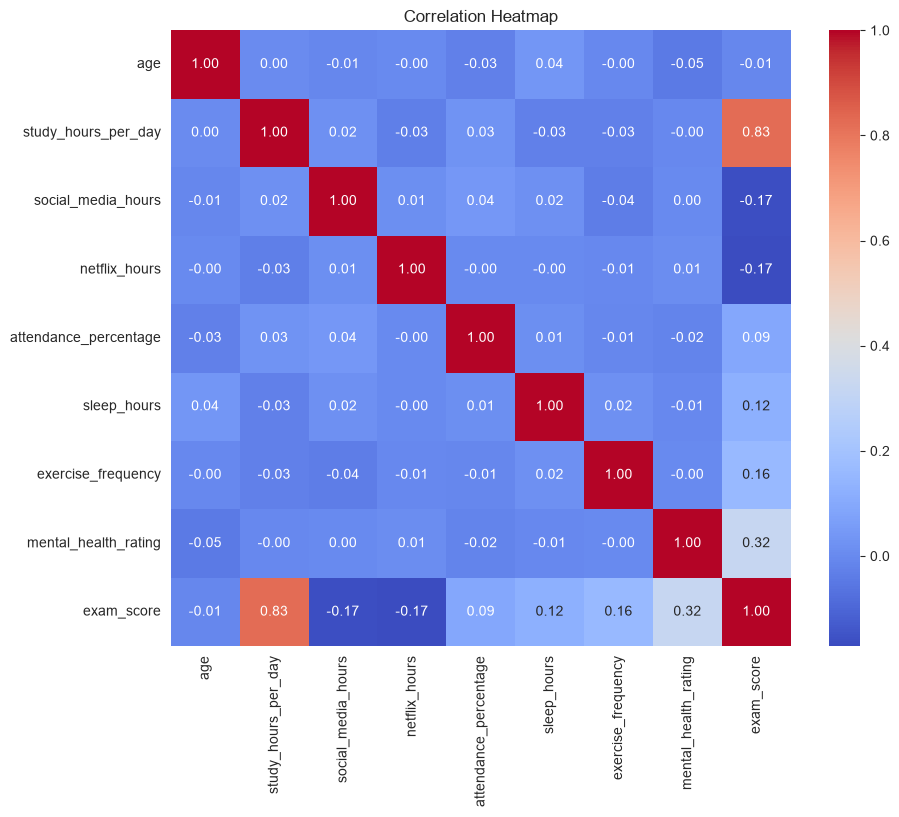

In [28]:
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [29]:
corr["exam_score"].sort_values(ascending=False)

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64

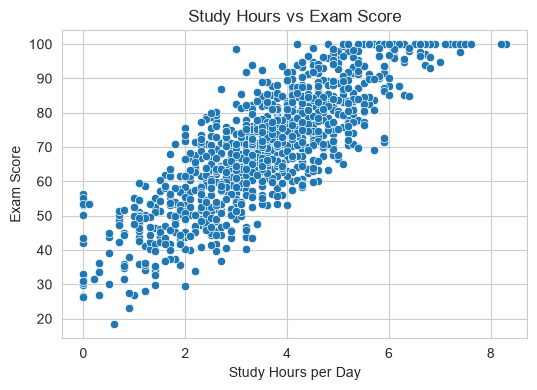

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="study_hours_per_day", y="exam_score", data=df)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (800, 8)
Testing set size: (200, 8)


In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [33]:
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Intercept:", model.intercept_)
coeff_df

Intercept: 5.906324174026565


,Feature,Coefficient
1,study_hours_per_day,9.533589
5,sleep_hours,1.989896
7,mental_health_rating,1.952032
6,exercise_frequency,1.315593
4,attendance_percentage,0.145895
0,age,0.052559
3,netflix_hours,-2.316592
2,social_media_hours,-2.701878


## 8. Predictions Karna

In [34]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results_df["Difference"] = results_df["Actual"] - results_df["Predicted"]
results_df.head(10)

,Actual,Predicted,Difference
0,64.2,66.052043,-1.852043
1,72.7,74.481327,-1.781327
2,79.0,78.104848,0.895152
3,79.5,74.380344,5.119656
4,58.2,61.424546,-3.224546
5,53.4,54.834888,-1.434888
6,70.8,75.917712,-5.117712
7,62.5,55.428013,7.071987
8,36.8,41.610086,-4.810086
9,67.6,72.816125,-5.216125


## 9. Model Evaluation
MAE, MSE, RMSE aur R² Score calculate karte hain.

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("-" * 30)
print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Results
------------------------------
Mean Absolute Error (MAE):  4.1302
Mean Squared Error (MSE):   25.9210
Root Mean Squared Error (RMSE): 5.0913
R² Score: 0.8989


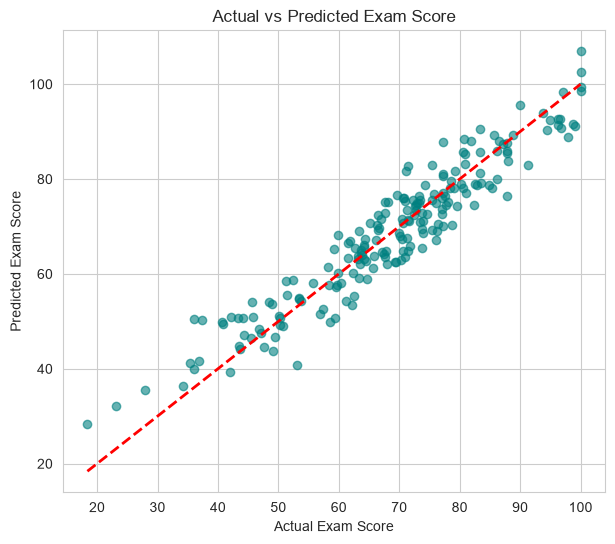

In [36]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

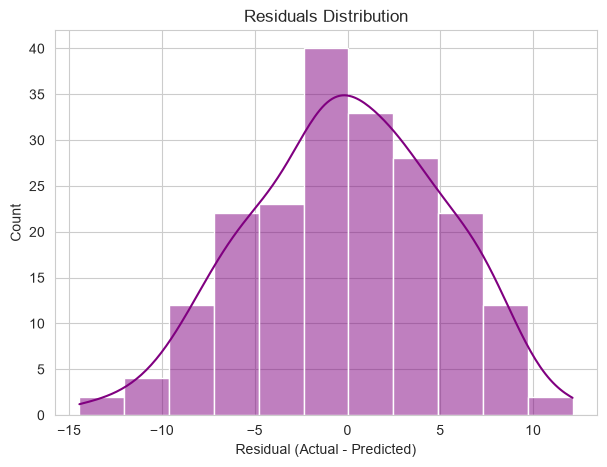

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()